In [451]:
import numpy as np
import pandas as pd
from scipy import signal
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from pathlib import Path

In [452]:
def sliding_window_normalize(window):
    # window: (n_channels, window_length)
    mu = window.mean(axis=1, keepdims=True)
    sigma = window.std(axis=1, keepdims=True) + 1e-8
    return (window - mu) / sigma

In [453]:
class EMGFeatureExtractor:
    """
    Extract time-domain features from EMG signals.
    Features: MAV, RMS, WL, ZC, SSC, AMP
    """

    def __init__(self, threshold_zc=0.01, threshold_ssc=0.01):
        """
        Args:
            threshold_zc: Threshold for zero crossing detection
            threshold_ssc: Threshold for slope sign change detection
        """
        self.threshold_zc = threshold_zc
        self.threshold_ssc = threshold_ssc

    def mean_absolute_value(self, signal_window):
        """Calculate Mean Absolute Value (MAV)"""
        return np.mean(np.abs(signal_window))

    def root_mean_square(self, signal_window):
        """Calculate Root Mean Square (RMS)"""
        return np.sqrt(np.mean(signal_window ** 2))

    def waveform_length(self, signal_window):
        """Calculate Waveform Length (WL)"""
        return np.sum(np.abs(np.diff(signal_window)))

    def zero_crossings(self, signal_window):
        """Calculate Zero Crossings (ZC)"""
        zc_count = 0
        for i in range(len(signal_window) - 1):
            if ((signal_window[i] > 0 and signal_window[i+1] < 0) or
                (signal_window[i] < 0 and signal_window[i+1] > 0)):
                if np.abs(signal_window[i] - signal_window[i+1]) >= self.threshold_zc:
                    zc_count += 1
        return zc_count

    def slope_sign_changes(self, signal_window):
        """Calculate Slope Sign Changes (SSC)"""
        ssc_count = 0
        for i in range(1, len(signal_window) - 1):
            diff1 = signal_window[i] - signal_window[i-1]
            diff2 = signal_window[i] - signal_window[i+1]

            if ((diff1 > 0 and diff2 > 0) or (diff1 < 0 and diff2 < 0)):
                if (np.abs(diff1) >= self.threshold_ssc or
                    np.abs(diff2) >= self.threshold_ssc):
                    ssc_count += 1
        return ssc_count

    def amplitude(self, signal_window):
        """Calculate Amplitude (max value - min value)"""
        return np.max(signal_window) - np.min(signal_window)

    def extract_features_from_window(self, window_data):
        """
        Extract all 6 features from a single channel window.

        Args:
            window_data: 1D array of EMG samples for one channel

        Returns:
            List of 6 features [MAV, RMS, WL, ZC, SSC, AMP]
        """
        features = [
            self.mean_absolute_value(window_data),
            self.root_mean_square(window_data),
            self.waveform_length(window_data),
            self.zero_crossings(window_data),
            self.slope_sign_changes(window_data),
            self.amplitude(window_data)
        ]
        return features

    def extract_features_multichannel(self, multichannel_window):
        """
        Extract features from all channels in a window.
            1D array of all features (6 features × n_channels)
        Args:
            multichannel_window: 2D array of shape (n_channels, window_length)

        Returns:
            1D array of all features (6 features × n_channels)
        """
        all_features = []
        normalized_window = sliding_window_normalize(multichannel_window)  # Normalize in-place
        for channel_data in normalized_window:
            channel_features = self.extract_features_from_window(channel_data)
            all_features.extend(channel_features)
        return np.array(all_features)

In [454]:

class EMGPreprocessor:
    """
    Preprocessing filters for raw EMG signals.

    Filters applied per channel:
      1. Notch filter    — removes power-line interference (50 or 60 Hz)
      2. Bandpass filter — keeps the physiologically relevant EMG band (20–450 Hz)
      3. (Optional) DC-removal — high-pass at 20 Hz is already included in the bandpass
    """

    def __init__(self, sampling_rate=200, lowcut=20.0, highcut=None,
                 notch_freq=50.0, notch_quality=30.0, filter_order=4):
        """
        Args:
            sampling_rate : Sampling rate of the EMG signal in Hz.
            lowcut        : Lower cutoff frequency for the bandpass (Hz).
                            Removes DC offset and motion artefacts.
            highcut       : Upper cutoff frequency for the bandpass (Hz).
                            Defaults to Nyquist - 1 Hz (fs/2 - 1) so it is
                            always valid regardless of sampling rate.
            notch_freq    : Power-line frequency to suppress (50 Hz or 60 Hz).
            notch_quality : Q-factor of the notch filter (higher → narrower notch).
            filter_order  : Order of the Butterworth bandpass filter.
        """
        self.fs = sampling_rate
        self.lowcut = lowcut
        self.highcut = highcut if highcut is not None else (sampling_rate / 2.0 - 1.0)
        self.notch_freq = notch_freq
        self.notch_quality = notch_quality
        self.filter_order = filter_order

        # Pre-compute filter coefficients once
        self._build_filters()

    # ------------------------------------------------------------------
    # Filter design
    # ------------------------------------------------------------------

    def _build_filters(self):
        nyq = self.fs / 2.0

        # Notch filter (IIR, second-order)
        self._b_notch, self._a_notch = signal.iirnotch(
            self.notch_freq / nyq, self.notch_quality
        )

        # Bandpass filter (Butterworth)
        low = self.lowcut / nyq
        high = self.highcut / nyq
        if not (0 < low < high < 1):
            raise ValueError(
                f"Invalid bandpass range [{self.lowcut}, {self.highcut}] Hz "
                f"for sampling rate {self.fs} Hz. "
                f"Ensure 0 < lowcut < highcut < fs/2."
            )
        self._b_bp, self._a_bp = signal.butter(
            self.filter_order, [low, high], btype='bandpass'
        )

    # ------------------------------------------------------------------
    # Filtering helpers
    # ------------------------------------------------------------------

    def _apply_notch(self, channel_signal):
        """Apply notch filter to a 1-D signal."""
        return signal.filtfilt(self._b_notch, self._a_notch, channel_signal)

    def _apply_bandpass(self, channel_signal):
        """Apply bandpass filter to a 1-D signal."""
        return signal.filtfilt(self._b_bp, self._a_bp, channel_signal)

    # ------------------------------------------------------------------
    # Public interface
    # ------------------------------------------------------------------

    def filter_channel(self, channel_signal):
        """
        Apply all filters to a single EMG channel.

        Args:
            channel_signal: 1-D array of raw EMG samples.

        Returns:
            1-D filtered array of the same length.
        """
        filtered = self._apply_notch(channel_signal)
        filtered = self._apply_bandpass(filtered)
        return filtered

    def filter_window(self, multichannel_window):
        """
        Filter a pre-windowed multi-channel segment.

        Args:
            multichannel_window: 2-D array of shape (n_channels, window_length).

        Returns:
            Filtered array of the same shape.
        """
        return np.array([
            self.filter_channel(ch) for ch in multichannel_window
        ])

    def filter_continuous(self, emg_data):
        """
        Filter a continuous multi-channel recording.

        Args:
            emg_data: 2-D array of shape (n_samples, n_channels).

        Returns:
            Filtered array of the same shape.
        """
        filtered = np.zeros_like(emg_data, dtype=float)
        for ch_idx in range(emg_data.shape[1]):
            filtered[:, ch_idx] = self.filter_channel(emg_data[:, ch_idx])
        return filtered


In [455]:
def augment_emg_data(
    emg_data,
    num_augmentations,
    noise_scale=0.03,
    scale_range=(0.75, 1.25),
    shift_range=(-0.05, 0.05),
):
    """
    Generate session-style augmented EMG windows.

    This augmentation is designed to mimic differences commonly seen across
    recording sessions (electrode placement, skin impedance, slight hardware
    drift, and channel coupling).

    Args:
        emg_data (np.ndarray): Window with shape (n_channels, n_samples).
        num_augmentations (int): Number of augmented copies to generate.
        noise_scale (float): Relative noise level (scaled by per-channel RMS).
        scale_range (tuple): Per-channel gain drift range.
        shift_range (tuple): Per-channel baseline drift range.

    Returns:
        list[np.ndarray]: Augmented windows only (original is not included).
    """
    if num_augmentations <= 0:
        return []

    augmented_data_list = []
    n_channels, n_samples = emg_data.shape

    for _ in range(num_augmentations):
        temp_data = emg_data.astype(float).copy()

        # 1) Session amplitude drift (per-channel gain mismatch).
        channel_gain = np.random.uniform(scale_range[0], scale_range[1], size=(n_channels, 1))
        temp_data *= channel_gain

        # 2) Session baseline drift (electrode/skin offset drift).
        baseline_shift = np.random.uniform(shift_range[0], shift_range[1], size=(n_channels, 1))
        temp_data += baseline_shift

        # 3) Cross-channel contamination (electrode cross-talk).
        if n_channels > 1:
            crosstalk = np.zeros_like(temp_data)
            for ch in range(n_channels):
                if np.random.rand() < 0.55:
                    src = np.random.randint(0, n_channels - 1)
                    if src >= ch:
                        src += 1
                    alpha = np.random.uniform(0.05, 0.20)
                    crosstalk[ch] += alpha * temp_data[src]
            temp_data += crosstalk

        # 4) Spectral/session drift via temporal compression/stretch.
        stretch = np.random.uniform(0.80, 1.20)
        warped_len = max(8, int(round(n_samples * stretch)))
        warped = signal.resample(temp_data, warped_len, axis=1)

        if warped_len >= n_samples:
            start = np.random.randint(0, warped_len - n_samples + 1)
            temp_data = warped[:, start:start + n_samples]
        else:
            pad_right = n_samples - warped_len
            temp_data = np.pad(warped, ((0, 0), (0, pad_right)), mode='edge')

        # 5) Sensor noise scaled by channel RMS.
        channel_rms = np.sqrt(np.mean(temp_data ** 2, axis=1, keepdims=True)) + 1e-8
        noise = np.random.normal(0, noise_scale, size=temp_data.shape) * channel_rms
        temp_data += noise

        augmented_data_list.append(temp_data)

    return augmented_data_list

In [456]:
def load_json_dataset(
    json_dir,
    feature_extractor,
    preprocessor=None,
    augment=False,
    num_augmentations=0,
    noise_scale=0.01,
    scale_range=(0.9, 1.1),
    shift_range=(-0.02, 0.02)
):
    """
    Load EMG windows from one or more JSON sources and return (X, y).

    Args:
        json_dir: A single path or a list/tuple of paths. Each path can be:
            - a directory containing JSON files, or
            - a specific JSON file.
        feature_extractor: EMGFeatureExtractor instance.
        preprocessor: Optional EMGPreprocessor instance.
        augment: Whether to add augmented copies per original window.
        num_augmentations: Number of augmented windows per original window.
        noise_scale: Noise scale used during augmentation.
        scale_range: Gain scaling range used during augmentation.
        shift_range: Baseline shift range used during augmentation.
    """
    LABEL_MAP = {
        'relax': 0,
        'grab': 1,
        'point': 2,
        'pinch': 3
    }

    # Accept either one source or many sources.
    if isinstance(json_dir, (str, Path)):
        sources = [Path(json_dir)]
    elif isinstance(json_dir, (list, tuple, set)):
        if len(json_dir) == 0:
            raise ValueError("json_dir list is empty")
        sources = [Path(p) for p in json_dir]
    else:
        raise ValueError("json_dir must be a path or a list/tuple/set of paths")

    json_files = []
    for src in sources:
        if src.is_dir():
            json_files.extend(sorted(src.glob("*.json")))
        elif src.is_file() and src.suffix.lower() == ".json":
            json_files.append(src)
        else:
            raise ValueError(f"Invalid source: {src}. Provide an existing directory or .json file.")

    # Remove metadata/helper JSON files and deduplicate while preserving sorted order.
    json_files = sorted({f for f in json_files if f.name != "mvc_rms_factors.json"})

    if len(json_files) == 0:
        raise ValueError("No JSON files found")

    print(f"Loading {len(json_files)} JSON files...")

    all_features = []
    all_labels = []

    for json_file in json_files:
        print(f"Processing: {json_file.name}")

        with open(json_file, "r") as f:
            file_data = json.load(f)

        samples = file_data["samples"]

        for window_obj in samples:
            gesture_label = window_obj["gesture"]

            if gesture_label not in LABEL_MAP:
                raise ValueError(f"Unknown gesture label: {gesture_label}")

            window = np.array(window_obj["data"])
            window = window.T  # (channels, samples)

            # Preprocess original window
            if preprocessor is not None:
                window = preprocessor.filter_window(window)

            # --- ORIGINAL SAMPLE ---
            features = feature_extractor.extract_features_multichannel(window)
            all_features.append(features)
            all_labels.append(LABEL_MAP[gesture_label])

            # --- AUGMENTED SAMPLES ---
            if augment and num_augmentations > 0:
                augmented_windows = augment_emg_data(
                    window,
                    num_augmentations,
                    noise_scale=noise_scale,
                    scale_range=scale_range,
                    shift_range=shift_range
                )

                for aug_window in augmented_windows:
                    features_aug = feature_extractor.extract_features_multichannel(aug_window)
                    all_features.append(features_aug)
                    all_labels.append(LABEL_MAP[gesture_label])

    X = np.array(all_features)
    y = np.array(all_labels)

    print(f"\nTotal windows: {X.shape[0]}")
    print(f"Features per window: {X.shape[1]}")

    return X, y

In [457]:
def create_sliding_windows(data, labels, window_size=200, overlap=0, sampling_rate=200,
                           discard_initial_ms=0):
    """
    Create sliding windows from continuous EMG data.

    Args:
        data: EMG data of shape (n_samples, n_channels)
        labels: Label for each sample
        window_size: Window size in milliseconds
        overlap: Overlap size in milliseconds
        sampling_rate: Sampling rate in Hz
        discard_initial_ms: Discard initial portion to remove muscle ramp-up

    Returns:
        windows: List of windowed data (n_channels, window_length)
        window_labels: Corresponding labels for each window
    """
    # Convert ms to samples
    window_samples = int(window_size * sampling_rate / 1000)
    stride_samples = int((window_size - overlap) * sampling_rate / 1000)
    discard_samples = int(discard_initial_ms * sampling_rate / 1000)

    windows = []
    window_labels = []

    # Start from discard_samples to skip ramp-up
    for start_idx in range(discard_samples, len(data) - window_samples + 1, stride_samples):
        end_idx = start_idx + window_samples

        # Extract window (transpose to get shape: n_channels × window_length)
        window = data[start_idx:end_idx, :].T

        # Use the most common label in the window (majority vote)
        window_label = np.bincount(labels[start_idx:end_idx]).argmax()

        windows.append(window)
        window_labels.append(window_label)

    return windows, np.array(window_labels)

In [458]:
def prepare_dataset(windows_list, labels_list, feature_extractor):
    """
    Convert windows to feature vectors.

    Args:
        windows_list: List of window arrays
        labels_list: Array of labels
        feature_extractor: EMGFeatureExtractor instance

    Returns:
        X: Feature matrix (n_windows, n_features)
        y: Labels array (n_windows,)
    """
    X = []
    for window in windows_list:
        features = feature_extractor.extract_features_multichannel(window)
        X.append(features)

    X = np.array(X)
    y = np.array(labels_list)

    return X, y

In [459]:
def plot_confusion_matrix(cm, class_names, title='Confusion Matrix'):
    """Plot confusion matrix as a heatmap"""
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

def save_model(model, scaler, feature_extractor, filepath='emg_svm_model.pkl'):
    """Save the trained model, scaler, and feature extractor"""
    model_data = {
        'model': model,
        'scaler': scaler,
        'feature_extractor': feature_extractor
    }
    joblib.dump(model_data, filepath)
    print(f"Model saved to {filepath}")

def load_model(filepath='emg_svm_model.pkl'):
    """Load a trained model"""
    model_data = joblib.load(filepath)
    return model_data['model'], model_data['scaler'], model_data['feature_extractor']

In [460]:
def train_svm_classifier(X_train, y_train, X_test, y_test, class_names):
    """
    Train and evaluate an SVM classifier.

    Args:
        X_train: Training features
        y_train: Training labels
        X_test: Test features
        y_test: Test labels
        class_names: List of class names for reporting

    Returns:
        model: Trained SVM model
        scaler: Fitted StandardScaler
        results: Dictionary containing evaluation metrics
    """
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train SVM with RBF kernel
    print("Training SVM classifier...")
    svm_model = SVC(kernel='rbf', C=10, gamma=0.001, random_state=42)
    svm_model.fit(X_train_scaled, y_train)

    # Predictions
    y_train_pred = svm_model.predict(X_train_scaled)
    y_test_pred = svm_model.predict(X_test_scaled)

    # Calculate accuracies
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"\n{'='*60}")
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"{'='*60}\n")

    # Classification report
    print("Classification Report:")
    print(classification_report(y_test, y_test_pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)

    # Cross-validation score
    print("\nPerforming 5-fold cross-validation...")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    print(f"Cross-validation scores: {cv_scores}")
    print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

    results = {
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'confusion_matrix': cm,
        'cv_scores': cv_scores,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }

    return svm_model, scaler, results

In [461]:
from sklearn.model_selection import GridSearchCV

def train_svm_classifier(X_train, y_train, X_test, y_test, class_names, perform_grid_search=False):
    """
    Train and evaluate an SVM classifier.

    Args:
        X_train: Training features
        y_train: Training labels
        X_test: Test features
        y_test: Test labels
        class_names: List of class names for reporting
        perform_grid_search: If True, perform GridSearchCV to find optimal C and gamma.

    Returns:
        model: Trained SVM model
        scaler: Fitted StandardScaler
        results: Dictionary containing evaluation metrics
    """
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train SVM with RBF kernel
    print("Training SVM classifier...")

    if perform_grid_search:
        print("Performing Grid Search for optimal C and gamma...")
        param_grid = {
            'C': [0.1, 0.5, 1, 5, 10, 100],
            'gamma': [1, 0.5, 0.1, 0.05, 0.01, 0.001],
            'kernel': ['rbf']
        }
        grid = GridSearchCV(SVC(random_state=42), param_grid, refit=True, verbose=2, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42))
        grid.fit(X_train_scaled, y_train)

        print("\nBest parameters found by Grid Search:")
        print(grid.best_params_)
        svm_model = grid.best_estimator_
    else:
        svm_model = SVC(kernel='rbf', C=10, gamma=0.001, random_state=42)
        svm_model.fit(X_train_scaled, y_train)

    # Predictions
    y_train_pred = svm_model.predict(X_train_scaled)
    y_test_pred = svm_model.predict(X_test_scaled)

    # Calculate accuracies
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"\n{'='*60}")
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"{'='*60}\n")

    # Classification report
    print("Classification Report:")
    print(classification_report(y_test, y_test_pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)

    # Cross-validation score
    print("\nPerforming 5-fold cross-validation...")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    print(f"Cross-validation scores: {cv_scores}")
    print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

    results = {
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'confusion_matrix': cm,
        'cv_scores': cv_scores,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    if perform_grid_search:
        results['best_params'] = grid.best_params_

    return svm_model, scaler, results

## Example Usage: Complete Training Pipeline

Below is a complete example showing how to use all the components together to train an SVM classifier for EMG gesture recognition.

In [462]:

# Parameters
SAMPLING_RATE = 200  # Hz
N_CHANNELS = 8  # Number of EMG channels
WINDOW_SIZE_MS = 200  # milliseconds
DISCARD_INITIAL_MS = 0  # Discard initial muscle ramp-up
CLASS_NAMES = ['Rest', 'Clench', 'Point', 'Pinch']

In [463]:

# Step 3: Preprocess & Extract Features
print("STEP 3: Preprocessing + Extracting Features (Big Six)")

# --- Preprocessing filters ---
# Notch : removes 50 Hz power-line noise (change to 60 if your grid is 60 Hz)
# Bandpass: keeps the physiologically relevant EMG band 20–95 Hz
#            (upper limit kept below Nyquist = fs/2 = 100 Hz for 200 Hz data)
preprocessor = EMGPreprocessor(
    sampling_rate=SAMPLING_RATE,
    lowcut=20.0,       # high-pass cut: removes DC offset & motion artefacts
    highcut=95.0,      # low-pass cut: rejects high-freq noise above EMG band
    notch_freq=50.0,   # power-line frequency (use 60.0 for North America / Japan)
    notch_quality=30.0,
    filter_order=4
)

feature_extractor = EMGFeatureExtractor(threshold_zc=0.01, threshold_ssc=0.01)

X, y = load_json_dataset(['./dataset_session_3'], feature_extractor, preprocessor=preprocessor, augment=True, num_augmentations=5)

print(f"✓ Extracted features from all windows")
print(f"Feature matrix shape: {X.shape}")
print(f"  → {X.shape[0]} windows")
print(f"  → {X.shape[1]} features per window")
print(f"  → {N_CHANNELS} channels × 6 features = {N_CHANNELS * 6} features")
print(f"\nFeatures per channel:")
print(f"  1. Mean Absolute Value (MAV)")
print(f"  2. Root Mean Square (RMS)")
print(f"  3. Waveform Length (WL)")
print(f"  4. Zero Crossings (ZC)")
print(f"  5. Slope Sign Changes (SSC)")
print(f"  6. Amplitude (AMP)")


STEP 3: Preprocessing + Extracting Features (Big Six)
Loading 4 JSON files...
Processing: emg_grab_3.json


Processing: emg_pinch_3.json
Processing: emg_point_3.json
Processing: emg_relax_3.json

Total windows: 240
Features per window: 48
✓ Extracted features from all windows
Feature matrix shape: (240, 48)
  → 240 windows
  → 48 features per window
  → 8 channels × 6 features = 48 features

Features per channel:
  1. Mean Absolute Value (MAV)
  2. Root Mean Square (RMS)
  3. Waveform Length (WL)
  4. Zero Crossings (ZC)
  5. Slope Sign Changes (SSC)
  6. Amplitude (AMP)


In [464]:
# Step 4: Split data into training and testing sets
print("STEP 4: Splitting Data")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

STEP 4: Splitting Data
Training set: 192 samples
Test set: 48 samples


In [465]:
# Step 5: Train SVM Classifier
print("STEP 5: Training SVM Classifier")

svm_model, scaler, results = train_svm_classifier(
    X_train, y_train, X_test, y_test, CLASS_NAMES, perform_grid_search=True
)

STEP 5: Training SVM Classifier
Training SVM classifier...
Performing Grid Search for optimal C and gamma...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.5, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.5, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.5, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.5, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.5, kernel=rbf; total time=   0.0s
[CV] END ..........

[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.05, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.05, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.05, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.05, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.05, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END ...................

STEP 6: Visualizing Confusion Matrix


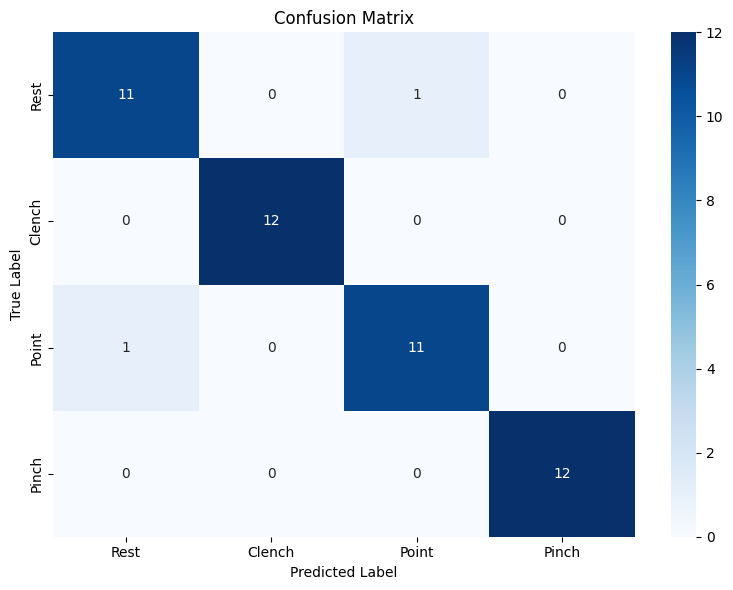

In [466]:
# Step 6: Visualize Results
print("STEP 6: Visualizing Confusion Matrix")
plot_confusion_matrix(results['confusion_matrix'], CLASS_NAMES)

STEP 6B: Evaluating on dataset_session_1
Loading 4 JSON files...
Processing: emg_grab_2.json
Processing: emg_pinch_2.json
Processing: emg_point_2.json
Processing: emg_relax_2.json

Total windows: 200
Features per window: 48
dataset_session_1 accuracy: 0.6250
Classification report on dataset_session_1:
              precision    recall  f1-score   support

        Rest       0.56      0.86      0.68        50
      Clench       1.00      0.20      0.33        50
       Point       0.46      0.46      0.46        50
       Pinch       0.78      0.98      0.87        50

    accuracy                           0.62       200
   macro avg       0.70      0.62      0.58       200
weighted avg       0.70      0.62      0.58       200



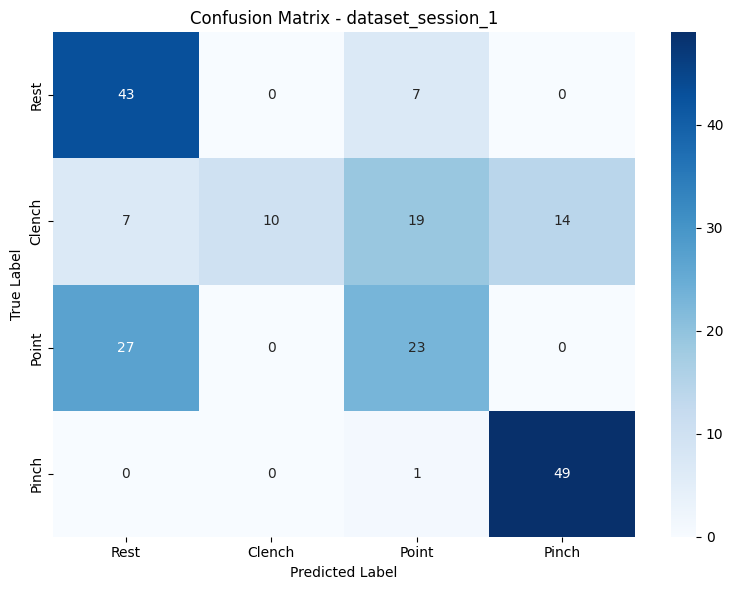

In [467]:
# Step 6B: Evaluate trained model on dataset_session_1 (before saving)
print("STEP 6B: Evaluating on dataset_session_1")

X_400, y_400 = load_json_dataset(
    'dataset_session_2',
    feature_extractor,
    preprocessor=preprocessor,
    augment=False,
    num_augmentations=0
)

X_400_scaled = scaler.transform(X_400)
y_400_pred = svm_model.predict(X_400_scaled)

acc_400 = accuracy_score(y_400, y_400_pred)
cm_400 = confusion_matrix(y_400, y_400_pred)

print(f"dataset_session_1 accuracy: {acc_400:.4f}")
print("Classification report on dataset_session_1:")
print(classification_report(y_400, y_400_pred, target_names=CLASS_NAMES))

plot_confusion_matrix(
    cm_400,
    CLASS_NAMES,
    title='Confusion Matrix - dataset_session_1'
 )

# Keep external evaluation metrics with the main results dictionary
results['dataset_session_1'] = {
    'accuracy': acc_400,
    'confusion_matrix': cm_400
}

In [468]:
# Step 7: Save the trained model
print("STEP 7: Saving Model")

save_model(svm_model, scaler, feature_extractor, filepath='/content/emg_svm_model.pkl')
print("\n Model saved successfully!")

STEP 7: Saving Model


FileNotFoundError: [Errno 2] No such file or directory: '/content/emg_svm_model.pkl'

In [ ]:
# !pip install micromlgen

In [ ]:
# # Install micromlgen
# # pip install micromlgen

# from micromlgen import port

# # After training your model
# c_code = port(svm_model)
# print(c_code)

In [ ]:
def save_model(model, scaler, feature_extractor, filepath='emg_svm_model.pkl'):
    """Save the trained model, scaler, and feature extractor"""
    model_data = {
        'model': model,
        'scaler': scaler,
        'feature_extractor': feature_extractor
    }
    joblib.dump(model_data, filepath)
    print(f"Model saved to {filepath}")

def load_model(filepath='emg_svm_model.pkl'):
    """Load a trained model"""
    model_data = joblib.load(filepath)
    return model_data['model'], model_data['scaler'], model_data['feature_extractor']

print("Functions 'save_model' and 'load_model' have been defined/re-defined in this cell.")
# Note: The model, scaler, and feature extractor were already saved in cell `ca815650`
# and loaded in a subsequent cell.

In [ ]:
def predict_emg_stream(emg_data, window_size_ms, overlap_ms, sampling_rate, feature_extractor, scaler, model, class_names):
    """
    Takes a continuous stream of EMG readings, divides them into windows,
    extracts features, scales them, and makes predictions.

    Args:
        emg_data (np.ndarray): 2D array of EMG readings (n_samples, n_channels).
        window_size_ms (int): Window size in milliseconds.
        overlap_ms (int): Overlap between windows in milliseconds.
        sampling_rate (int): Sampling rate in Hz.
        feature_extractor (EMGFeatureExtractor): Fitted feature extractor instance.
        scaler (StandardScaler): Fitted StandardScaler instance.
        model (SVC): Trained SVM model.
        class_names (list): List of class names for interpretation.

    Returns:
        list: A list of predicted gesture names for each window.
    """

    if not isinstance(emg_data, np.ndarray):
        emg_data = np.array(emg_data) # Convert tensor to numpy array if applicable

    if emg_data.ndim != 2:
        raise ValueError("Input emg_data must be a 2D array (n_samples, n_channels).")

    # create_sliding_windows expects labels, so we create dummy labels
    dummy_labels = np.zeros(emg_data.shape[0], dtype=int)

    # Generate windows from the continuous stream
    windows, _ = create_sliding_windows(
        emg_data, dummy_labels, window_size=window_size_ms, overlap=overlap_ms,
        sampling_rate=sampling_rate
    )

    if not windows:
        print("No windows created from the input stream.")
        return []

    # Prepare features for prediction
    X_predict = []
    for window_data in windows:
        # Feature extraction using the provided feature_extractor
        features = feature_extractor.extract_features_multichannel(window_data)
        X_predict.append(features)

    X_predict = np.array(X_predict)

    # Scale the features using the provided scaler
    X_predict_scaled = scaler.transform(X_predict)

    # Make predictions using the provided model
    predictions = model.predict(X_predict_scaled)

    # Map numerical predictions to class names
    predicted_gestures = [class_names[p] for p in predictions]

    return predicted_gestures

# --- Example Usage ---

print("\n--- Demonstrating real-time prediction function ---")

# Re-loading the model components for explicit demonstration in this example
# These variables were already loaded in a previous cell, but are re-assigned here
# to show their origin for the 'predict_emg_stream' function.
loaded_svm_model, loaded_scaler, loaded_feature_extractor = load_model('/content/emg_svm_model.pkl')
print('Model, scaler, and feature extractor assigned for example usage.')

# Create some dummy EMG data for demonstration (e.g., 5 seconds of 8-channel data)
# Make sure N_CHANNELS is defined, if not, assume 8 as per the notebook
if 'N_CHANNELS' not in globals():
    N_CHANNELS = 8

dummy_emg_stream_length_samples = SAMPLING_RATE * 5 # 5 seconds of data
dummy_emg_stream = np.random.randn(dummy_emg_stream_length_samples, N_CHANNELS) * 0.1 # Small random values

# Define overlap for streaming (e.g., 50% overlap)
OVERLAP_MS = 100 # 100ms overlap for 200ms window

print(f"Processing dummy EMG stream of shape: {dummy_emg_stream.shape}")
print(f"Using window size: {WINDOW_SIZE_MS}ms, overlap: {OVERLAP_MS}ms, sampling rate: {SAMPLING_RATE}Hz")

stream_predictions = predict_emg_stream(
    dummy_emg_stream,
    WINDOW_SIZE_MS,
    OVERLAP_MS,
    SAMPLING_RATE,
    loaded_feature_extractor,
    loaded_scaler,
    loaded_svm_model,
    CLASS_NAMES
)

print("Predicted gestures for the stream ", stream_predictions)
print("Total predictions made:", len(stream_predictions))